# Outlier Detection and Impact on ML Models
This notebook demonstrates:
- Generating normal and skewed datasets
- Visualizing with histograms and boxplots
- Detecting outliers using ±3σ and IQR rules
- Comparing sensitivity of Linear Regression vs Decision Tree to outliers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)

# Generate normal and skewed datasets
normal_data = np.random.normal(loc=50, scale=5, size=200)
normal_data_with_outliers = np.append(normal_data, [90, 95, 100])

skewed_data = np.random.exponential(scale=10, size=200)
skewed_data_with_outliers = np.append(skewed_data, [80, 90, 100])

df = pd.DataFrame({
    "Normal": normal_data_with_outliers,
    "Skewed": skewed_data_with_outliers
})
df.head()

,Normal,Skewed
0,52.483571,20.986086
1,49.308678,13.500342
2,53.238443,11.940744
3,57.615149,12.122876
4,48.829233,4.454923


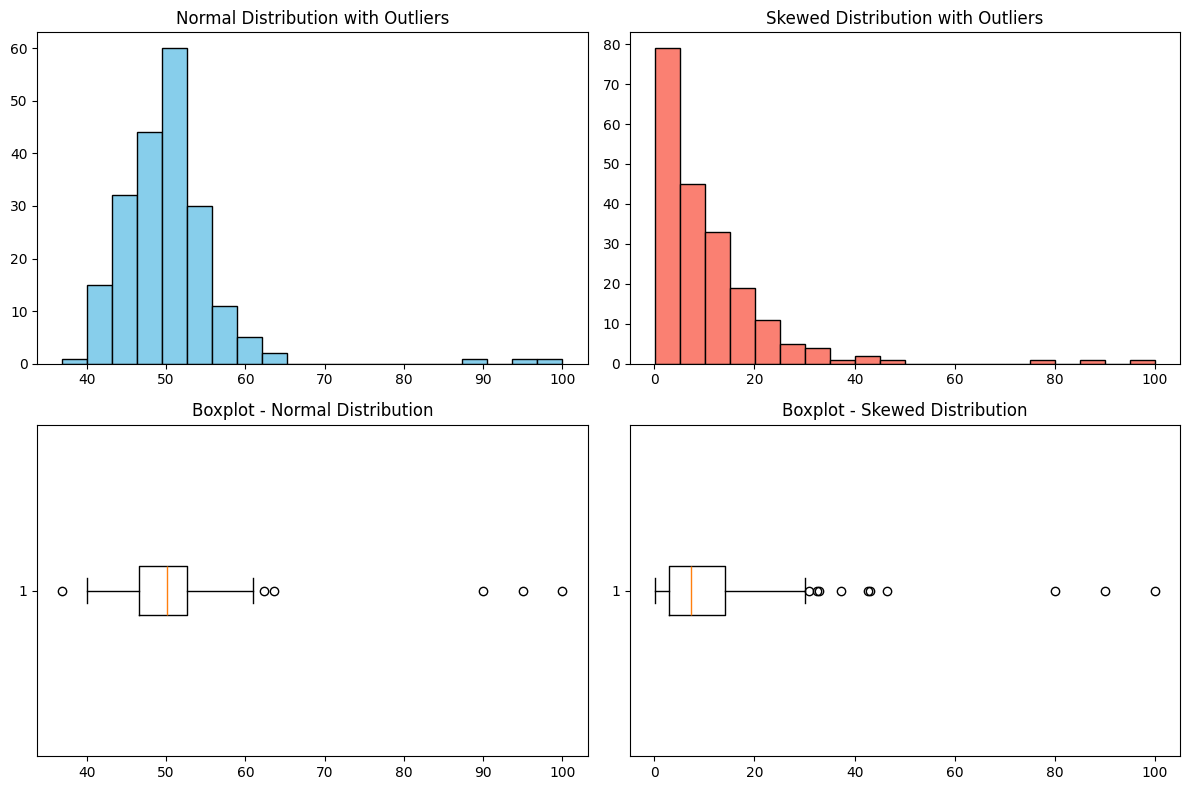

In [2]:
# Histograms and Boxplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0,0].hist(df["Normal"], bins=20, color='skyblue', edgecolor='black')
axs[0,0].set_title("Normal Distribution with Outliers")

axs[0,1].hist(df["Skewed"], bins=20, color='salmon', edgecolor='black')
axs[0,1].set_title("Skewed Distribution with Outliers")

axs[1,0].boxplot(df["Normal"], vert=False)
axs[1,0].set_title("Boxplot - Normal Distribution")

axs[1,1].boxplot(df["Skewed"], vert=False)
axs[1,1].set_title("Boxplot - Skewed Distribution")

plt.tight_layout()
plt.show()

In [3]:
# Detect outliers - Normal using ±3σ rule
mean_normal = np.mean(df["Normal"])
std_normal = np.std(df["Normal"])
normal_outliers = df["Normal"][(df["Normal"] > mean_normal + 3*std_normal) |
                               (df["Normal"] < mean_normal - 3*std_normal)]
normal_outliers

,Normal
200,90.0
201,95.0
202,100.0


In [4]:
# Detect outliers - Skewed using IQR rule
Q1 = df["Skewed"].quantile(0.25)
Q3 = df["Skewed"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
skewed_outliers = df["Skewed"][(df["Skewed"] < lower_bound) | (df["Skewed"] > upper_bound)]
skewed_outliers

,Skewed
41,37.235570
49,32.873799
60,30.981035
102,32.490919
126,46.570049
177,43.154586
182,42.687739
200,80.000000
201,90.000000
202,100.000000


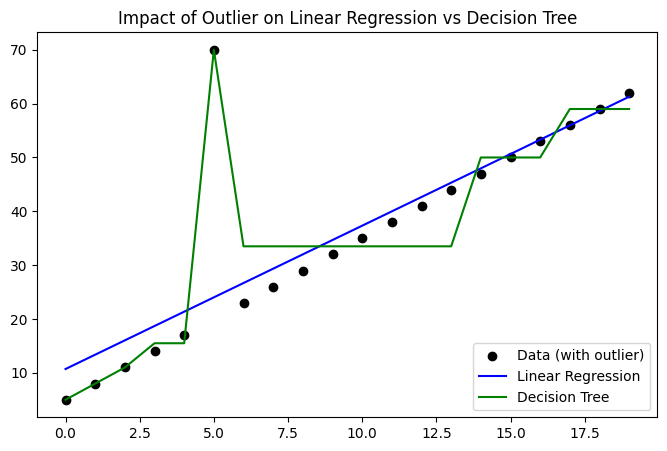

In [5]:
# Model Sensitivity Demo
X = np.arange(0, 20, 1).reshape(-1, 1)
y = 3 * X.flatten() + 5
y_with_outliers = y.copy()
y_with_outliers[5] += 50

lr = LinearRegression().fit(X, y_with_outliers)
y_pred_lr = lr.predict(X)

tree = DecisionTreeRegressor(max_depth=3).fit(X, y_with_outliers)
y_pred_tree = tree.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X, y_with_outliers, label="Data (with outlier)", color="black")
plt.plot(X, y_pred_lr, label="Linear Regression", color="blue")
plt.plot(X, y_pred_tree, label="Decision Tree", color="green")
plt.legend()
plt.title("Impact of Outlier on Linear Regression vs Decision Tree")
plt.show()